# Heatmaps de Correlación - Cambio de Opinión por Tipo de Item y Candidato

Este notebook genera heatmaps de correlación de Spearman entre variables de cambio de opinión desagregadas por tipo de item (progresista/conservador) y candidato (izquierda/derecha), junto con características psicológicas de los participantes.

## Variables analizadas:
- Cambio_Opinion_Pro_Izq: Cambio de opinión en items progresistas con candidato de izquierda
- Cambio_Opinion_Pro_Der: Cambio de opinión en items progresistas con candidato de derecha
- Cambio_Opinion_Con_Izq: Cambio de opinión en items conservadores con candidato de izquierda
- Cambio_Opinion_Con_Der: Cambio de opinión en items conservadores con candidato de derecha
- Indice_Conservadurismo: Índice de tendencias conservadoras
- Indice_Progresismo: Índice de tendencias progresistas
- Autopercepcion_Izq_Der: Autopercepción en eje Izquierda-Derecha
- Autopercepcion_Con_Pro: Autopercepción en eje Conservador-Progresista
- Autopercepcion_Per_Antiper: Autopercepción en eje Peronista-Antiperonista

## Método:
- Correlación de Spearman (no paramétrica)
- Test de significancia bilateral
- Visualización con mapa de calor divergente (rojo-blanco-azul)

In [1]:
# Importar librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

print("Librerías cargadas exitosamente.")

Librerías cargadas exitosamente.


In [2]:
# Definir rutas de archivos (relativas al notebook)
# El notebook está en Código/, los datos en Data/Procesados/, gráficos en Gráficos/
ruta_base = os.path.abspath(os.path.join(os.getcwd(), '..'))
ruta_datos = os.path.join(ruta_base, 'Data', 'Procesados')
ruta_graficos = os.path.join(ruta_base, 'Gráficos')

print(f"Ruta base del proyecto: {ruta_base}")

# Crear carpeta de gráficos si no existe
os.makedirs(ruta_graficos, exist_ok=True)

# Cargar datos
df_Generales = pd.read_excel(os.path.join(ruta_datos, 'Generales_con_Congruencia.xlsx'))
df_Ballotage = pd.read_excel(os.path.join(ruta_datos, 'Ballotage_con_Congruencia.xlsx'))

print(f"Datos cargados:")
print(f"  Generales: {len(df_Generales)} participantes")
print(f"  Ballotage: {len(df_Ballotage)} participantes")

Ruta base del proyecto: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis
Datos cargados:
  Generales: 2786 participantes
  Ballotage: 1254 participantes


In [3]:
# Definir las variables para la correlación
variables = [
    'CO_Pro_Izq',
    'CO_Pro_Der',
    'CO_Con_Izq',
    'CO_Con_Der',
    'Indice_Conservadurismo',
    'Indice_Progresismo',
    'Autopercepcion_Izq_Der',
    'Autopercepcion_Con_Pro',
    'Autopercepcion_Per_Antiper'
]

# Etiquetas más cortas para visualización
etiquetas = [
    'CO Pro→Izq',
    'CO Pro→Der',
    'CO Con→Izq',
    'CO Con→Der',
    'Conservadurismo',
    'Progresismo',
    'Izq-Der',
    'Con-Pro',
    'Per-Antiper'
]

print(f"Variables a correlacionar: {len(variables)}")
for var, label in zip(variables, etiquetas):
    print(f"  - {var} → {label}")

Variables a correlacionar: 9
  - CO_Pro_Izq → CO Pro→Izq
  - CO_Pro_Der → CO Pro→Der
  - CO_Con_Izq → CO Con→Izq
  - CO_Con_Der → CO Con→Der
  - Indice_Conservadurismo → Conservadurismo
  - Indice_Progresismo → Progresismo
  - Autopercepcion_Izq_Der → Izq-Der
  - Autopercepcion_Con_Pro → Con-Pro
  - Autopercepcion_Per_Antiper → Per-Antiper


In [4]:
def calcular_matriz_correlacion_spearman(df, variables):
    """
    Calcula matriz de correlación de Spearman con p-valores.
    
    Parámetros:
    -----------
    df : DataFrame
        DataFrame con los datos
    variables : list
        Lista de nombres de columnas a correlacionar
    
    Retorna:
    --------
    corr_matrix : DataFrame
        Matriz de correlación
    p_matrix : DataFrame
        Matriz de p-valores
    n_matrix : DataFrame
        Matriz con el número de observaciones para cada par
    """
    n_vars = len(variables)
    corr_matrix = np.zeros((n_vars, n_vars))
    p_matrix = np.zeros((n_vars, n_vars))
    n_matrix = np.zeros((n_vars, n_vars))
    
    for i in range(n_vars):
        for j in range(n_vars):
            if i == j:
                # Diagonal: correlación perfecta
                corr_matrix[i, j] = 1.0
                p_matrix[i, j] = 0.0
                n_matrix[i, j] = df[variables[i]].notna().sum()
            else:
                # Extraer datos válidos (sin NaN) para ambas variables
                datos_validos = df[[variables[i], variables[j]]].dropna()
                n = len(datos_validos)
                n_matrix[i, j] = n
                
                if n >= 3:  # Mínimo 3 observaciones para correlación
                    rho, p_valor = stats.spearmanr(datos_validos[variables[i]], 
                                                    datos_validos[variables[j]])
                    corr_matrix[i, j] = rho
                    p_matrix[i, j] = p_valor
                else:
                    corr_matrix[i, j] = np.nan
                    p_matrix[i, j] = np.nan
    
    # Convertir a DataFrames con etiquetas
    corr_df = pd.DataFrame(corr_matrix, index=etiquetas, columns=etiquetas)
    p_df = pd.DataFrame(p_matrix, index=etiquetas, columns=etiquetas)
    n_df = pd.DataFrame(n_matrix, index=etiquetas, columns=etiquetas)
    
    return corr_df, p_df, n_df

print("Función de cálculo de correlaciones definida.")

Función de cálculo de correlaciones definida.


In [5]:
def crear_anotaciones_con_significancia(corr_matrix, p_matrix, decimales=2):
    """
    Crea matriz de anotaciones con valores de correlación y asteriscos de significancia.
    
    Parámetros:
    -----------
    corr_matrix : DataFrame
        Matriz de correlación
    p_matrix : DataFrame
        Matriz de p-valores
    decimales : int
        Número de decimales para mostrar
    
    Retorna:
    --------
    annot_matrix : ndarray
        Matriz de strings con valores y asteriscos
    """
    n_rows, n_cols = corr_matrix.shape
    annot_matrix = np.empty((n_rows, n_cols), dtype=object)
    
    for i in range(n_rows):
        for j in range(n_cols):
            valor = corr_matrix.iloc[i, j]
            p_valor = p_matrix.iloc[i, j]
            
            if np.isnan(valor):
                annot_matrix[i, j] = 'N/A'
            else:
                # Formatear valor con decimales especificados
                texto = f"{valor:.{decimales}f}"
                
                # Agregar asteriscos de significancia
                if not np.isnan(p_valor):
                    if p_valor < 0.001:
                        texto += "***"
                    elif p_valor < 0.01:
                        texto += "**"
                    elif p_valor < 0.05:
                        texto += "*"
                
                annot_matrix[i, j] = texto
    
    return annot_matrix

print("Función de anotaciones definida.")

Función de anotaciones definida.


In [6]:
def crear_heatmap_correlacion(corr_matrix, p_matrix, titulo, nombre_archivo, guardar=True):
    """
    Crea y guarda un heatmap de correlación con significancia.
    
    Parámetros:
    -----------
    corr_matrix : DataFrame
        Matriz de correlación
    p_matrix : DataFrame
        Matriz de p-valores
    titulo : str
        Título del gráfico
    nombre_archivo : str
        Nombre del archivo para guardar (sin extensión)
    guardar : bool
        Si True, guarda el gráfico en formato SVG
    """
    # Crear anotaciones
    anotaciones = crear_anotaciones_con_significancia(corr_matrix, p_matrix, decimales=2)
    
    # Crear figura con tamaño ajustado para 9 variables
    fig, ax = plt.subplots(figsize=(14, 11))
    
    # Crear heatmap
    sns.heatmap(
        corr_matrix,
        annot=anotaciones,
        fmt='',
        cmap='RdBu_r',
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.5,
        cbar_kws={
            'label': 'Correlación de Spearman (ρ)',
            'shrink': 0.8
        },
        ax=ax
    )
    
    # Configurar título y etiquetas
    ax.set_title(titulo, fontsize=16, fontweight='bold', pad=20)
    
    # Rotar etiquetas para mejor legibilidad
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    # Agregar nota sobre significancia
    nota_significancia = '* p < 0.05   ** p < 0.01   *** p < 0.001'
    plt.figtext(0.5, 0.02, nota_significancia, 
                ha='center', fontsize=10, style='italic')
    
    plt.tight_layout(rect=[0, 0.03, 1, 1])
    
    # Guardar si se solicita
    if guardar:
        ruta_archivo = os.path.join(ruta_graficos, f'{nombre_archivo}.svg')
        plt.savefig(ruta_archivo, format='svg', bbox_inches='tight', facecolor='white')
        print(f"Gráfico guardado: {ruta_archivo}")
    
    plt.show()
    
    # Mostrar estadísticas de significancia
    n_total = corr_matrix.shape[0] * corr_matrix.shape[1]
    n_diagonal = corr_matrix.shape[0]
    n_comparaciones = (n_total - n_diagonal) // 2  # Solo triángulo superior
    
    # Extraer solo triángulo superior (sin diagonal)
    mask_superior = np.triu(np.ones_like(p_matrix, dtype=bool), k=1)
    p_valores_superiores = p_matrix.values[mask_superior]
    p_valores_superiores = p_valores_superiores[~np.isnan(p_valores_superiores)]
    
    n_sig_001 = np.sum(p_valores_superiores < 0.001)
    n_sig_01 = np.sum((p_valores_superiores >= 0.001) & (p_valores_superiores < 0.01))
    n_sig_05 = np.sum((p_valores_superiores >= 0.01) & (p_valores_superiores < 0.05))
    n_no_sig = np.sum(p_valores_superiores >= 0.05)
    
    print(f"\nEstadísticas de significancia ({titulo}):")
    print(f"  Total de correlaciones únicas: {len(p_valores_superiores)}")
    print(f"  p < 0.001: {n_sig_001} ({n_sig_001/len(p_valores_superiores)*100:.1f}%)")
    print(f"  p < 0.01:  {n_sig_01} ({n_sig_01/len(p_valores_superiores)*100:.1f}%)")
    print(f"  p < 0.05:  {n_sig_05} ({n_sig_05/len(p_valores_superiores)*100:.1f}%)")
    print(f"  p ≥ 0.05:  {n_no_sig} ({n_no_sig/len(p_valores_superiores)*100:.1f}%)")

print("Función de creación de heatmap definida.")

Función de creación de heatmap definida.


## Heatmap - Elecciones Generales

In [7]:
# Calcular matriz de correlación para Generales
corr_gen, p_gen, n_gen = calcular_matriz_correlacion_spearman(df_Generales, variables)

print("Matriz de correlación - Generales:")
print(corr_gen.round(3))
print("\nMatriz de p-valores - Generales:")
print(p_gen.round(4))
print("\nNúmero de observaciones - Generales:")
print(n_gen.astype(int))

Matriz de correlación - Generales:
                 CO Pro→Izq  CO Pro→Der  CO Con→Izq  CO Con→Der  \
CO Pro→Izq            1.000       0.455      -0.052       0.032   
CO Pro→Der            0.455       1.000      -0.037      -0.180   
CO Con→Izq           -0.052      -0.037       1.000       0.440   
CO Con→Der            0.032      -0.180       0.440       1.000   
Conservadurismo      -0.034      -0.006      -0.163      -0.124   
Progresismo          -0.106      -0.112       0.057       0.004   
Izq-Der               0.000       0.038      -0.050       0.007   
Con-Pro               0.032      -0.006       0.025       0.002   
Per-Antiper          -0.016       0.001      -0.051       0.004   

                 Conservadurismo  Progresismo  Izq-Der  Con-Pro  Per-Antiper  
CO Pro→Izq                -0.034       -0.106    0.000    0.032       -0.016  
CO Pro→Der                -0.006       -0.112    0.038   -0.006        0.001  
CO Con→Izq                -0.163        0.057   -0.050   

Gráfico guardado: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Gráficos\Heatmap_Correlacion_CO_Desagregado_Generales.svg


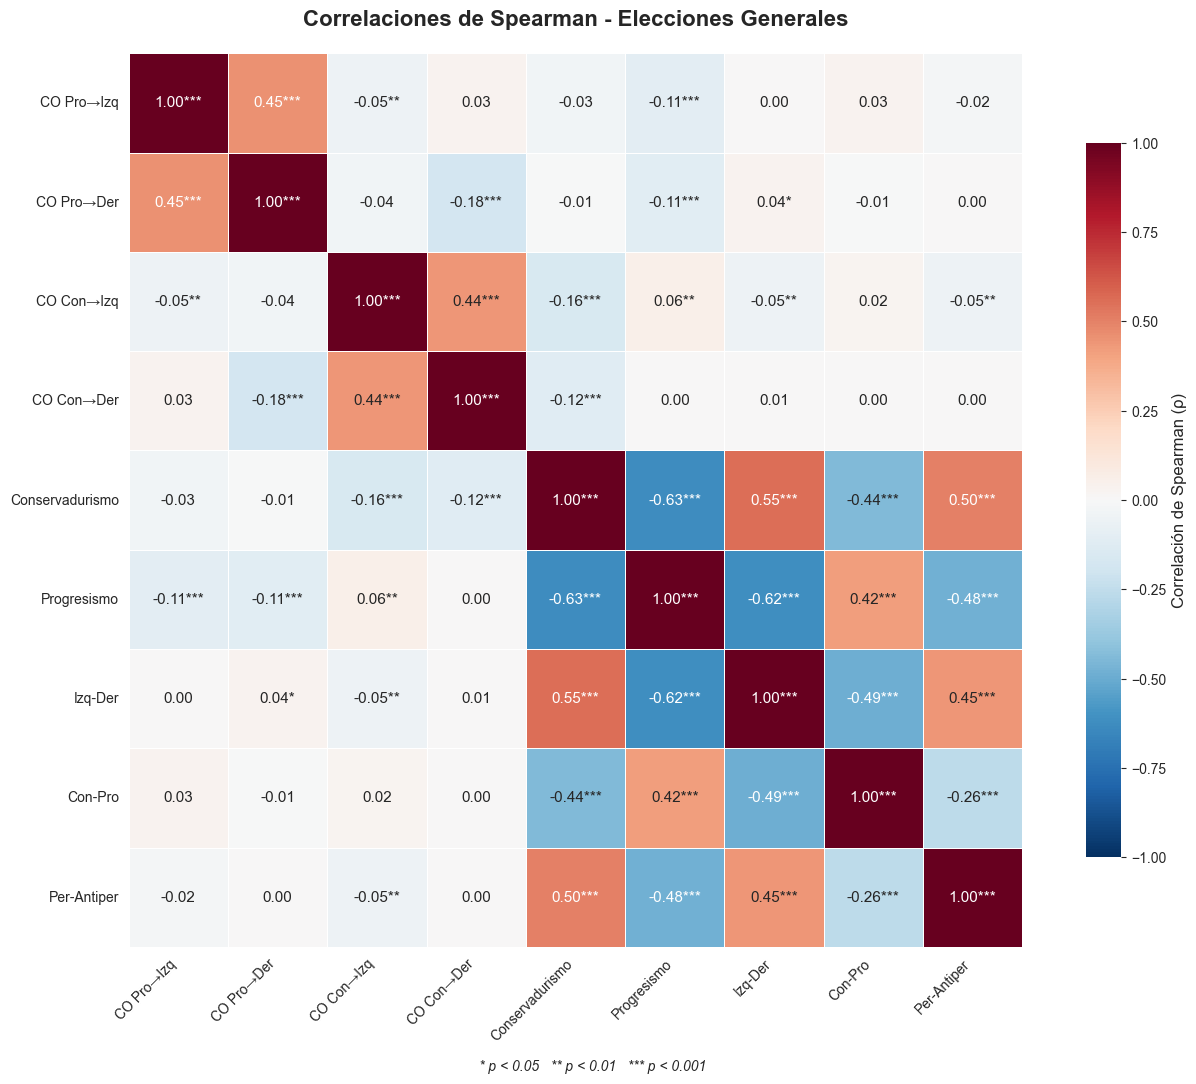


Estadísticas de significancia (Correlaciones de Spearman - Elecciones Generales):
  Total de correlaciones únicas: 36
  p < 0.001: 17 (47.2%)
  p < 0.01:  4 (11.1%)
  p < 0.05:  1 (2.8%)
  p ≥ 0.05:  14 (38.9%)


In [8]:
# Crear heatmap para Generales
crear_heatmap_correlacion(
    corr_gen,
    p_gen,
    'Correlaciones de Spearman - Elecciones Generales',
    'Heatmap_Correlacion_CO_Desagregado_Generales',
    guardar=True
)

## Heatmap - Ballotage

In [9]:
# Calcular matriz de correlación para Ballotage
corr_bal, p_bal, n_bal = calcular_matriz_correlacion_spearman(df_Ballotage, variables)

print("Matriz de correlación - Ballotage:")
print(corr_bal.round(3))
print("\nMatriz de p-valores - Ballotage:")
print(p_bal.round(4))
print("\nNúmero de observaciones - Ballotage:")
print(n_bal.astype(int))

Matriz de correlación - Ballotage:
                 CO Pro→Izq  CO Pro→Der  CO Con→Izq  CO Con→Der  \
CO Pro→Izq            1.000       0.540      -0.070      -0.065   
CO Pro→Der            0.540       1.000      -0.055      -0.143   
CO Con→Izq           -0.070      -0.055       1.000       0.587   
CO Con→Der           -0.065      -0.143       0.587       1.000   
Conservadurismo       0.025       0.031      -0.175      -0.143   
Progresismo          -0.125      -0.156       0.064       0.052   
Izq-Der               0.028       0.073      -0.060      -0.045   
Con-Pro              -0.045      -0.033       0.036       0.014   
Per-Antiper          -0.019       0.015      -0.109      -0.043   

                 Conservadurismo  Progresismo  Izq-Der  Con-Pro  Per-Antiper  
CO Pro→Izq                 0.025       -0.125    0.028   -0.045       -0.019  
CO Pro→Der                 0.031       -0.156    0.073   -0.033        0.015  
CO Con→Izq                -0.175        0.064   -0.060   

Gráfico guardado: c:\Users\Patricio\Documents\Codigo\Python\Investigacion\Tesis\Gráficos\Heatmap_Correlacion_CO_Desagregado_Ballotage.svg


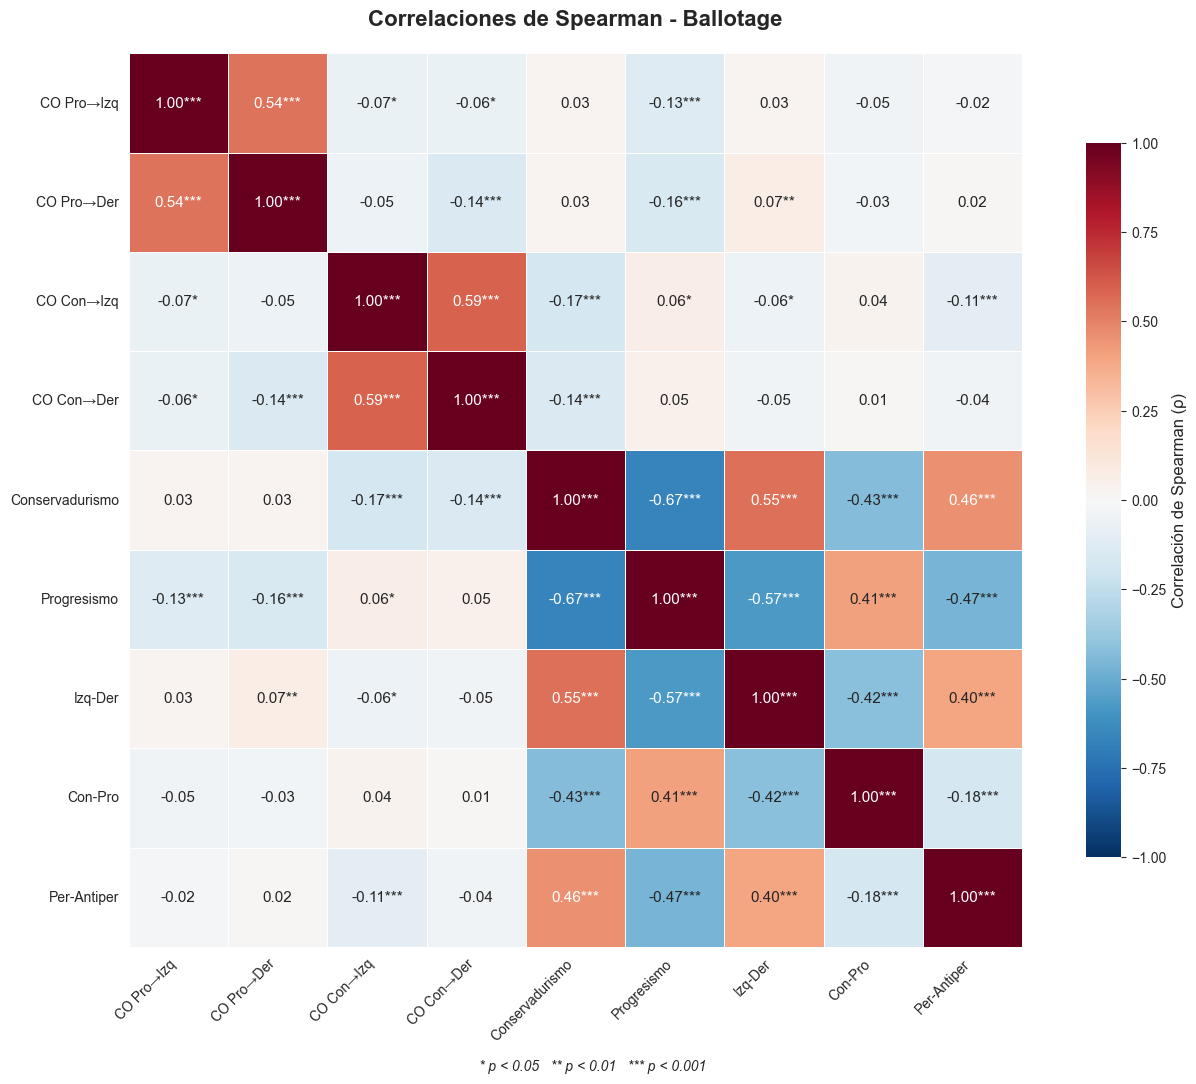


Estadísticas de significancia (Correlaciones de Spearman - Ballotage):
  Total de correlaciones únicas: 36
  p < 0.001: 18 (50.0%)
  p < 0.01:  1 (2.8%)
  p < 0.05:  4 (11.1%)
  p ≥ 0.05:  13 (36.1%)


In [10]:
# Crear heatmap para Ballotage
crear_heatmap_correlacion(
    corr_bal,
    p_bal,
    'Correlaciones de Spearman - Ballotage',
    'Heatmap_Correlacion_CO_Desagregado_Ballotage',
    guardar=True
)

## Análisis Comparativo

Comparación de las correlaciones entre Generales y Ballotage.

In [11]:
# Calcular diferencias entre correlaciones
diff_corr = corr_gen - corr_bal

print("Diferencias en correlaciones (Generales - Ballotage):")
print(diff_corr.round(3))
print("\nNota: Valores positivos indican correlaciones más fuertes en Generales")
print("      Valores negativos indican correlaciones más fuertes en Ballotage")

Diferencias en correlaciones (Generales - Ballotage):
                 CO Pro→Izq  CO Pro→Der  CO Con→Izq  CO Con→Der  \
CO Pro→Izq            0.000      -0.086       0.018       0.097   
CO Pro→Der           -0.086       0.000       0.018      -0.037   
CO Con→Izq            0.018       0.018       0.000      -0.147   
CO Con→Der            0.097      -0.037      -0.147       0.000   
Conservadurismo      -0.060      -0.036       0.011       0.019   
Progresismo           0.020       0.044      -0.007      -0.048   
Izq-Der              -0.028      -0.035       0.009       0.053   
Con-Pro               0.078       0.027      -0.011      -0.012   
Per-Antiper           0.003      -0.014       0.057       0.047   

                 Conservadurismo  Progresismo  Izq-Der  Con-Pro  Per-Antiper  
CO Pro→Izq                -0.060        0.020   -0.028    0.078        0.003  
CO Pro→Der                -0.036        0.044   -0.035    0.027       -0.014  
CO Con→Izq                 0.011      

In [12]:
# Identificar las diferencias más grandes
# Extraer triángulo superior para evitar duplicados
mask = np.triu(np.ones_like(diff_corr, dtype=bool), k=1)
diff_superior = diff_corr.where(mask)

# Convertir a formato largo para análisis
diferencias_lista = []
for i in range(len(etiquetas)):
    for j in range(i+1, len(etiquetas)):
        if not np.isnan(diff_superior.iloc[i, j]):
            diferencias_lista.append({
                'Variable 1': etiquetas[i],
                'Variable 2': etiquetas[j],
                'Diferencia': diff_superior.iloc[i, j],
                'Corr Generales': corr_gen.iloc[i, j],
                'Corr Ballotage': corr_bal.iloc[i, j],
                'p Generales': p_gen.iloc[i, j],
                'p Ballotage': p_bal.iloc[i, j]
            })

df_diferencias = pd.DataFrame(diferencias_lista)
df_diferencias = df_diferencias.sort_values('Diferencia', key=abs, ascending=False)

print("\nMayores diferencias entre elecciones (ordenadas por magnitud):")
print("="*100)
for idx, row in df_diferencias.head(10).iterrows():
    print(f"{row['Variable 1']:20s} vs {row['Variable 2']:20s}")
    print(f"  Generales:  ρ={row['Corr Generales']:6.3f} (p={row['p Generales']:.4f})")
    print(f"  Ballotage:  ρ={row['Corr Ballotage']:6.3f} (p={row['p Ballotage']:.4f})")
    print(f"  Diferencia: Δρ={row['Diferencia']:6.3f}")
    print()


Mayores diferencias entre elecciones (ordenadas por magnitud):
CO Con→Izq           vs CO Con→Der          
  Generales:  ρ= 0.440 (p=0.0000)
  Ballotage:  ρ= 0.587 (p=0.0000)
  Diferencia: Δρ=-0.147

CO Pro→Izq           vs CO Con→Der          
  Generales:  ρ= 0.032 (p=0.0873)
  Ballotage:  ρ=-0.065 (p=0.0221)
  Diferencia: Δρ= 0.097

Con-Pro              vs Per-Antiper         
  Generales:  ρ=-0.264 (p=0.0000)
  Ballotage:  ρ=-0.178 (p=0.0000)
  Diferencia: Δρ=-0.086

CO Pro→Izq           vs CO Pro→Der          
  Generales:  ρ= 0.455 (p=0.0000)
  Ballotage:  ρ= 0.540 (p=0.0000)
  Diferencia: Δρ=-0.086

CO Pro→Izq           vs Con-Pro             
  Generales:  ρ= 0.032 (p=0.0884)
  Ballotage:  ρ=-0.045 (p=0.1077)
  Diferencia: Δρ= 0.078

Izq-Der              vs Con-Pro             
  Generales:  ρ=-0.486 (p=0.0000)
  Ballotage:  ρ=-0.419 (p=0.0000)
  Diferencia: Δρ=-0.067

CO Pro→Izq           vs Conservadurismo     
  Generales:  ρ=-0.034 (p=0.0705)
  Ballotage:  ρ= 0.025 (p=0.3

## Análisis de Patrones de Congruencia/Incongruencia

Examinar las correlaciones entre las 4 variables de cambio de opinión para identificar patrones.

In [13]:
# Extraer correlaciones entre las 4 variables de CO
co_vars = ['CO Pro→Izq', 'CO Pro→Der', 'CO Con→Izq', 'CO Con→Der']

print("Correlaciones entre variables de Cambio de Opinión - GENERALES:")
print("="*70)
for i, var1 in enumerate(co_vars):
    for j, var2 in enumerate(co_vars):
        if i < j:  # Solo triángulo superior
            idx1 = etiquetas.index(var1)
            idx2 = etiquetas.index(var2)
            rho = corr_gen.iloc[idx1, idx2]
            p = p_gen.iloc[idx1, idx2]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{var1:15s} vs {var2:15s}: ρ = {rho:6.3f} (p={p:.4f}) {sig}")

print("\n" + "="*70)
print("Correlaciones entre variables de Cambio de Opinión - BALLOTAGE:")
print("="*70)
for i, var1 in enumerate(co_vars):
    for j, var2 in enumerate(co_vars):
        if i < j:  # Solo triángulo superior
            idx1 = etiquetas.index(var1)
            idx2 = etiquetas.index(var2)
            rho = corr_bal.iloc[idx1, idx2]
            p = p_bal.iloc[idx1, idx2]
            sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
            print(f"{var1:15s} vs {var2:15s}: ρ = {rho:6.3f} (p={p:.4f}) {sig}")

Correlaciones entre variables de Cambio de Opinión - GENERALES:
CO Pro→Izq      vs CO Pro→Der     : ρ =  0.455 (p=0.0000) ***
CO Pro→Izq      vs CO Con→Izq     : ρ = -0.052 (p=0.0062) **
CO Pro→Izq      vs CO Con→Der     : ρ =  0.032 (p=0.0873) ns
CO Pro→Der      vs CO Con→Izq     : ρ = -0.037 (p=0.0522) ns
CO Pro→Der      vs CO Con→Der     : ρ = -0.180 (p=0.0000) ***
CO Con→Izq      vs CO Con→Der     : ρ =  0.440 (p=0.0000) ***

Correlaciones entre variables de Cambio de Opinión - BALLOTAGE:
CO Pro→Izq      vs CO Pro→Der     : ρ =  0.540 (p=0.0000) ***
CO Pro→Izq      vs CO Con→Izq     : ρ = -0.070 (p=0.0138) *
CO Pro→Izq      vs CO Con→Der     : ρ = -0.065 (p=0.0221) *
CO Pro→Der      vs CO Con→Izq     : ρ = -0.055 (p=0.0521) ns
CO Pro→Der      vs CO Con→Der     : ρ = -0.143 (p=0.0000) ***
CO Con→Izq      vs CO Con→Der     : ρ =  0.587 (p=0.0000) ***


## Resumen de Resultados

Los heatmaps muestran las correlaciones de Spearman entre:
- **4 variables de cambio de opinión desagregadas:**
  - Items Progresistas → Candidato Izquierda
  - Items Progresistas → Candidato Derecha
  - Items Conservadores → Candidato Izquierda
  - Items Conservadores → Candidato Derecha
- **Índices psicológicos:** Conservadurismo, Progresismo
- **Autopercepciones políticas:** Izq-Der, Con-Pro, Per-Antiper

### Interpretación del mapa de calor:
- **Azul intenso**: Correlación positiva fuerte (ρ cercano a +1)
- **Blanco**: Sin correlación (ρ cercano a 0)
- **Rojo intenso**: Correlación negativa fuerte (ρ cercano a -1)

### Significancia estadística:
- `*` = p < 0.05 (significativo)
- `**` = p < 0.01 (muy significativo)
- `***` = p < 0.001 (altamente significativo)

### Patrones esperados de congruencia:
Si los participantes responden de manera ideológicamente congruente, esperaríamos:
- Correlación positiva entre Pro→Izq y Con→Der (congruencia)
- Correlación positiva entre Pro→Der y Con→Izq (incongruencia)
- Correlaciones negativas entre congruentes e incongruentes